In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time
import math

import torch
import cupy as cp

BLOCK_SIZE = 16

In [ ]:
# Connection check to GPU and check if it's available
print(torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
!nvidia-smi

In [ ]:
# Load data
data = np.loadtxt('MLoGPU_data3_train.csv', delimiter=',')
X = data[:, :-1]
y = data[:, -1]

X_cp = cp.array(X, dtype=cp.float32)
y_cp = cp.array(y, dtype=cp.int32)

# Take all classes
classes = cp.unique(y_cp)
classes = classes.astype(int).tolist()

In [ ]:
# Data splitting
X_train_cp, X_test_cp, y_train_cp, y_test_cp = train_test_split(X_cp, y_cp, test_size=0.25, random_state=42)
print(X_train_cp.shape, X_test_cp.shape, y_train_cp.shape, y_test_cp.shape)

In [ ]:
# Data normalization
mean_train = X_train_cp.mean()
std_train = X_train_cp.std()

X_train_norm = (X_train_cp - mean_train) / std_train
X_test_norm = (X_test_cp - mean_train) / std_train

print(X_train_norm.min(), X_train_norm.max())
print(X_test_norm.min(), X_test_norm.max())

In [ ]:
# No train needed for kNN
print(cp.unique(y_train_cp), cp.unique(y_test_cp))

In [ ]:
compute_distances = cp.RawKernel(r'''
extern "C" __global__
void compute_distances(
    const float* X_train, const float* X_test, float* distances,
    const int n_train, const int n_test, const int features
){
    int tId = blockIdx.x * blockDim.x + threadIdx.x;
    if (tId >= n_test) return;

    for (int i = 0; i < n_train; i++) {

        float dist = 0.0f;

        for (int j = 0; j < features; j++) {
            float diff = X_train[i * features + j] -
                         X_test[tId * features + j];
            dist += diff * diff;
        }

        distances[tId * n_train + i] = dist;
    }
}
''', 'compute_distances')

In [ ]:
n_train = X_train_norm.shape[0]
n_test = X_test_norm.shape[0]
features = X_train_norm.shape[1]

distances = cp.zeros((n_test, n_train), dtype=cp.float32)
labels = cp.tile(y_train_cp, (n_test, 1))

print(labels, labels.shape)

In [ ]:
threads = 256
blocks = math.ceil(n_test / threads)

cp.cuda.Stream.null.synchronize()
start_time = time.time()

compute_distances(
    (blocks,),
    (threads,),
    (X_train_norm, X_test_norm, distances,
     n_train, n_test, features)
)

sorted_idx = cp.argsort(distances, axis=1)
sorted_distances = cp.take_along_axis(distances, sorted_idx, axis=1)
sorted_labels = y_train_cp[sorted_idx]

# Merge distances + labels
dists_gp = cp.stack((sorted_distances, sorted_labels), axis=2)  # shape (n_test, n_train, 2)


cp.cuda.Stream.null.synchronize()
print(f"Execution time : {time.time() - start_time}")

[[[4.87608910e-02 3.00000000e+00]
  [1.99385196e-01 3.00000000e+00]
  [3.22899252e-01 4.00000000e+00]
  ...
  [1.18467133e+02 4.00000000e+00]
  [1.37600662e+02 3.00000000e+00]
  [2.65973907e+02 2.00000000e+00]]

 [[5.69388807e-01 4.00000000e+00]
  [1.01247501e+00 4.00000000e+00]
  [1.19365585e+00 2.00000000e+00]
  ...
  [1.34006653e+02 4.00000000e+00]
  [1.59365875e+02 3.00000000e+00]
  [3.00417847e+02 2.00000000e+00]]

 [[1.44393981e-01 4.00000000e+00]
  [2.95895904e-01 3.00000000e+00]
  [3.31478059e-01 4.00000000e+00]
  ...
  [1.44544769e+02 4.00000000e+00]
  [1.66928360e+02 3.00000000e+00]
  [3.09832916e+02 2.00000000e+00]]

 ...

 [[2.38399446e-01 4.00000000e+00]
  [2.40807191e-01 4.00000000e+00]
  [2.57161975e-01 5.00000000e+00]
  ...
  [1.32367813e+02 4.00000000e+00]
  [1.54797653e+02 3.00000000e+00]
  [2.91212830e+02 2.00000000e+00]]

 [[2.74550349e-01 5.00000000e+00]
  [3.62664253e-01 3.00000000e+00]
  [3.66618276e-01 4.00000000e+00]
  ...
  [1.28258743e+02 4.00000000e+00]
  [1

In [13]:
dists = dists_gp.get()
print(np.unique(dists[:, :, 1]), dists.shape)

print(dists)

[1. 2. 3. 4. 5. 6. 7.] (1000, 3000, 2)
[[[4.87608910e-02 3.00000000e+00]
  [1.99385196e-01 3.00000000e+00]
  [3.22899252e-01 4.00000000e+00]
  ...
  [1.18467133e+02 4.00000000e+00]
  [1.37600662e+02 3.00000000e+00]
  [2.65973907e+02 2.00000000e+00]]

 [[5.69388807e-01 4.00000000e+00]
  [1.01247501e+00 4.00000000e+00]
  [1.19365585e+00 2.00000000e+00]
  ...
  [1.34006653e+02 4.00000000e+00]
  [1.59365875e+02 3.00000000e+00]
  [3.00417847e+02 2.00000000e+00]]

 [[1.44393981e-01 4.00000000e+00]
  [2.95895904e-01 3.00000000e+00]
  [3.31478059e-01 4.00000000e+00]
  ...
  [1.44544769e+02 4.00000000e+00]
  [1.66928360e+02 3.00000000e+00]
  [3.09832916e+02 2.00000000e+00]]

 ...

 [[2.38399446e-01 4.00000000e+00]
  [2.40807191e-01 4.00000000e+00]
  [2.57161975e-01 5.00000000e+00]
  ...
  [1.32367813e+02 4.00000000e+00]
  [1.54797653e+02 3.00000000e+00]
  [2.91212830e+02 2.00000000e+00]]

 [[2.74550349e-01 5.00000000e+00]
  [3.62664253e-01 3.00000000e+00]
  [3.66618276e-01 4.00000000e+00]
  ...

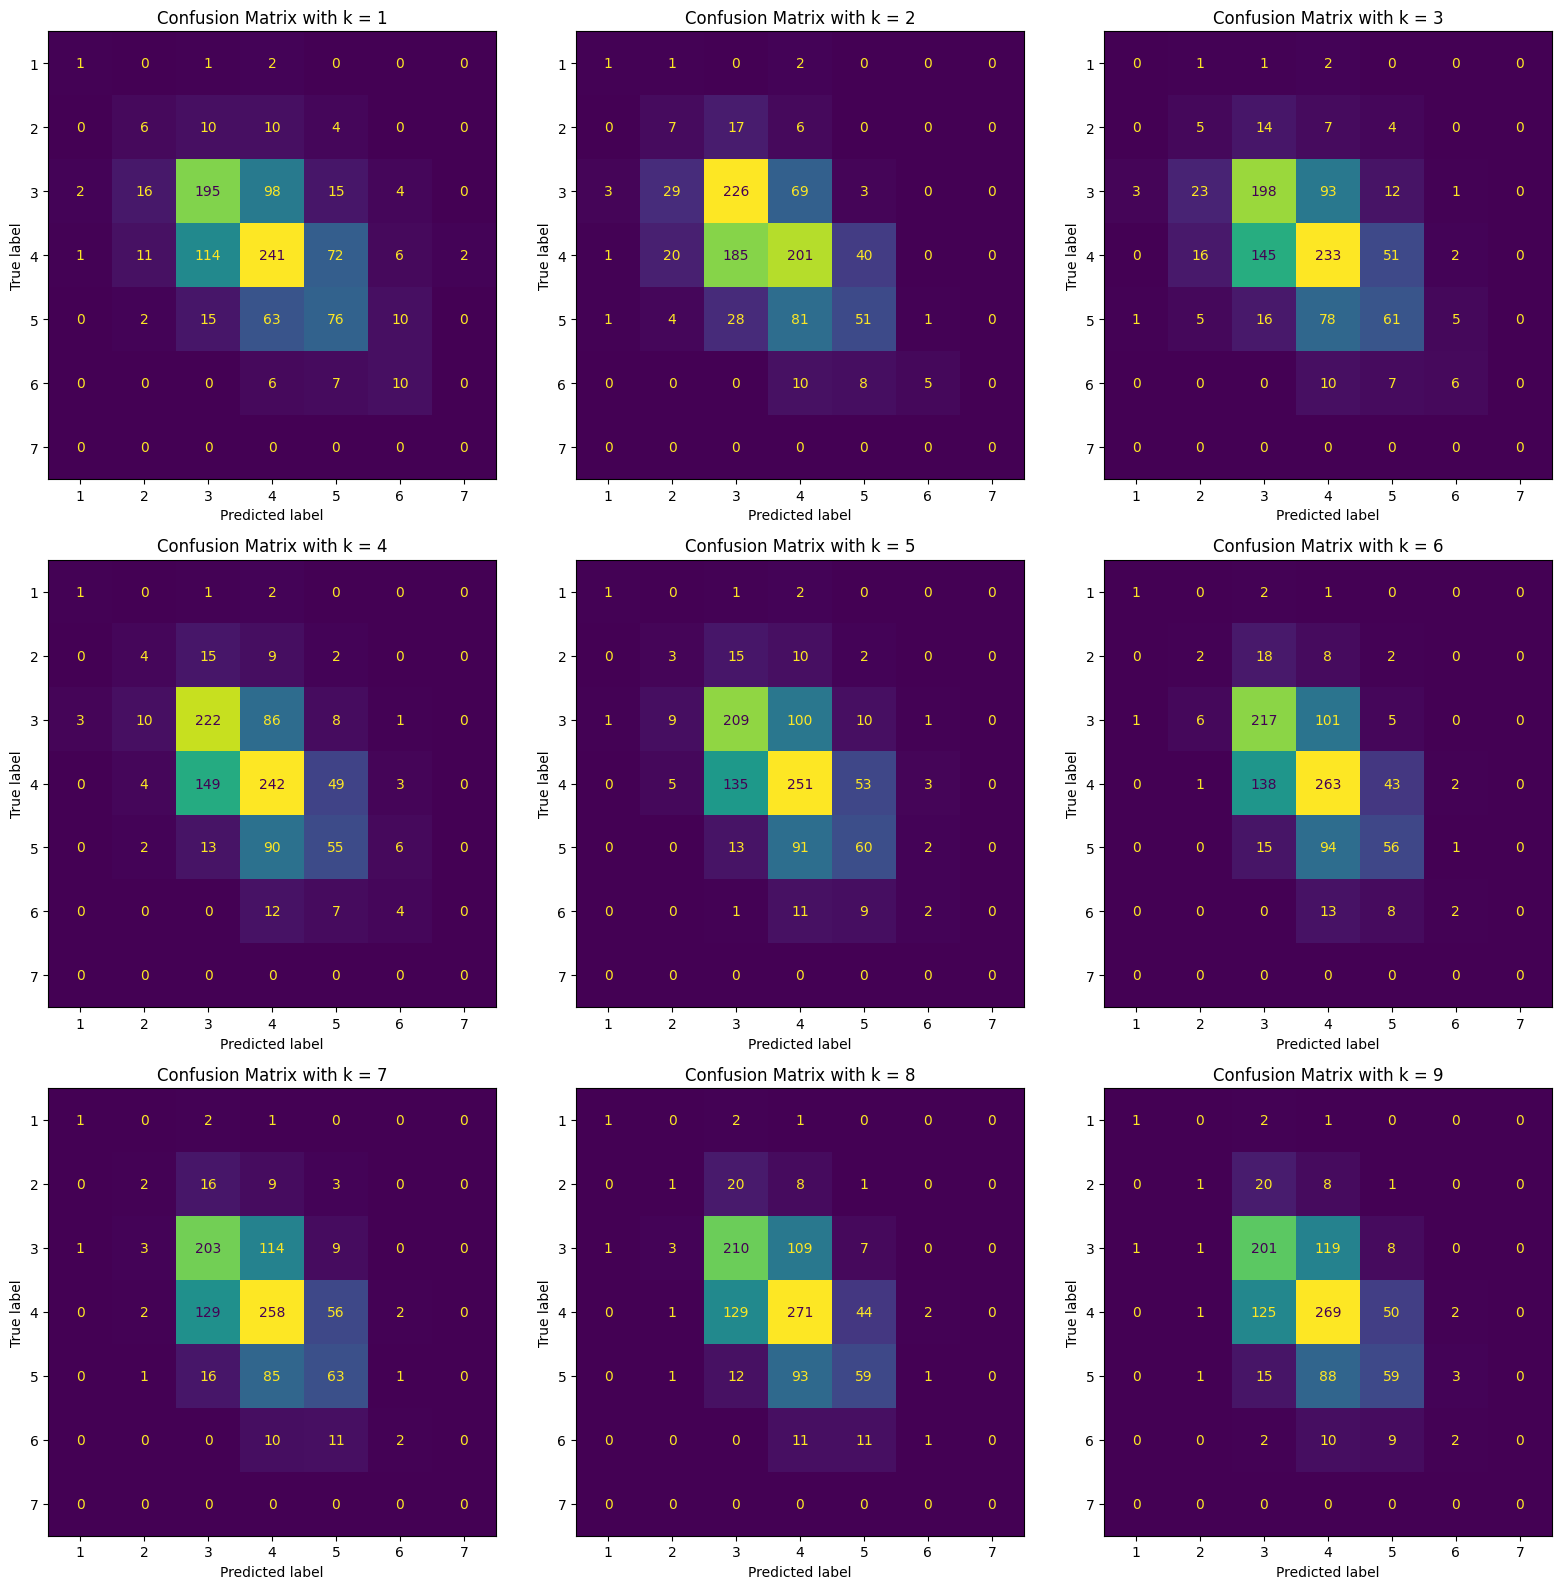

In [15]:
preds = np.zeros_like(y_test_cp)
y_test = y_test_cp.get()
accuracies = []
exec_times = []
k_values = range(1, 10)

fig, axs = plt.subplots(3, 3, figsize=(16, 16))
axs = axs.ravel()

for K_VALUE in k_values:
    ax = axs[K_VALUE - 1]

    start_time = time.time()

    # Take nearest k train samples' labels for each test sample
    nearest_labels = dists[:, :K_VALUE, 1]

    # Compute mode for each test sample
    preds_res = stats.mode(nearest_labels, keepdims=True, axis=1)
    preds = np.array(preds_res)[0, ...]

    exec_times.append(time.time() - start_time)

    # Confusion matrix
    cm = confusion_matrix(y_test, preds, labels=classes)

    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix with k = {K_VALUE}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")


    accuracies.append(np.sum(np.trace(cm)) / len(preds) * 100)

plt.tight_layout()
plt.show()

(0.0, 100.0)

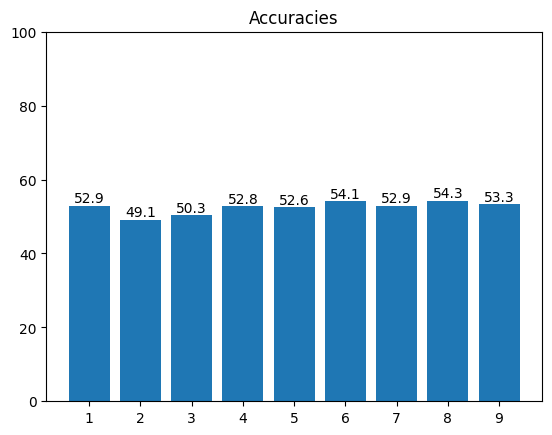

In [16]:
# Accuracies
fig, ax = plt.subplots()
bars = ax.bar(k_values, accuracies)
ax.bar_label(bars)
plt.title('Accuracies')
plt.xticks(k_values)
plt.ylim((0,100))